In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data
import yfinance as yf
import datetime as dt

In [5]:
stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2026, 3, 31)
power = yf.download(stock, start, end)

[*********************100%***********************]  1 of 1 completed


In [7]:
power.tail()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2026-03-23,302.100006,304.350006,293.100006,298.000000,23771660
2026-03-24,299.000000,309.000000,292.399994,309.000000,24123621
2026-03-25,295.000000,302.250000,294.200012,299.899994,16423641
2026-03-27,295.500000,297.299988,290.299988,294.450012,27444747
2026-03-30,296.100006,297.899994,292.000000,292.049988,23105779


In [8]:
power.shape

(4557, 5)

In [9]:
power.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4557 entries, 2007-10-05 to 2026-03-30
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (Close, POWERGRID.NS)   4557 non-null   float64
 1   (High, POWERGRID.NS)    4557 non-null   float64
 2   (Low, POWERGRID.NS)     4557 non-null   float64
 3   (Open, POWERGRID.NS)    4557 non-null   float64
 4   (Volume, POWERGRID.NS)  4557 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 213.6 KB


In [10]:
power.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4557.000000,4557.000000,4557.000000,4557.000000,4.557000e+03
mean,91.857041,93.007509,90.720758,91.898056,1.198621e+07
std,80.890640,81.784432,79.968442,80.893539,1.990689e+07
min,18.038853,19.282911,16.172765,19.189606,0.000000e+00
25%,35.253834,35.785334,34.756381,35.301966,5.017948e+06
50%,65.217010,66.248608,64.438886,65.360381,8.676278e+06
75%,102.588470,103.939848,101.476133,102.780452,1.390816e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [11]:
power.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [30]:
power = power.reset_index()

In [31]:
power.head()

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,0,2007-10-05,30.896236,33.629602,25.536998,27.579345,855215656
1,1,2007-10-08,29.314579,31.940452,29.130306,31.940452,126671715
2,2,2007-10-09,31.310846,31.587253,27.748259,29.329924,116725709
3,3,2007-10-10,31.602617,32.247569,31.326210,32.124720,67931378
4,4,2007-10-11,35.134487,36.854358,31.326205,36.854358,106320954


In [32]:
power.columns

MultiIndex([( 'index',             ''),
            (  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [33]:
power.to_csv("powergrid.csv")

In [34]:
powerdf = pd.read_csv("powergrid.csv")

In [35]:
powerdf.head()

,Price,index,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,0.0,2007-10-05,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,1.0,2007-10-08,29.314579010009766,31.940452479116296,29.13030638373306,31.940452479116296,126671715
3,2,2.0,2007-10-09,31.31084632873535,31.58725309319482,27.74825868243687,29.32992354655404,116725709
4,3,3.0,2007-10-10,31.602617263793945,32.247569316618566,31.326210431319556,32.1247202155724,67931378


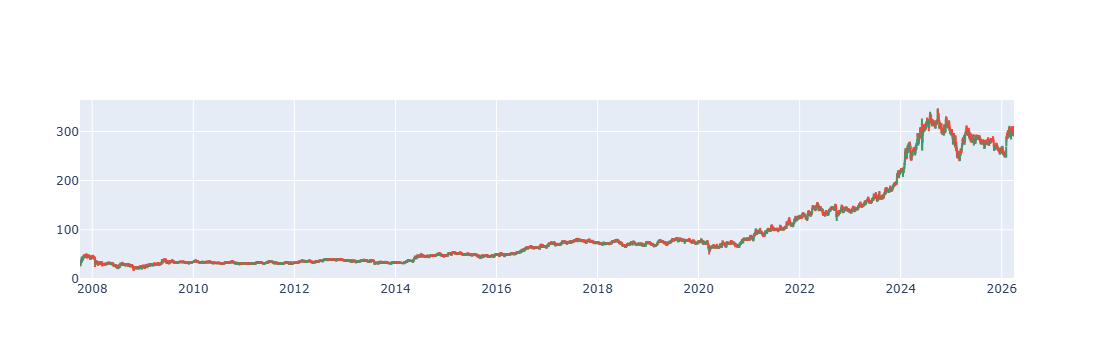

In [36]:
import plotly.graph_objects as go

fig = go.Figure(data = [go.Candlestick(x = powerdf['Date'], open = powerdf['Open'],
                                       low = powerdf['Low'],
                                       high = powerdf['High'],
                                       close = powerdf['Close'])])
fig.update_layout(xaxis_rangeslider_visible = False)
fig.show()

In [37]:
powerdf = powerdf.drop(["Date"], axis = 1)

In [38]:
powerdf.head()

,Price,index,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,0.0,30.896236419677734,33.62960189509571,25.536998153531204,27.579344583114715,855215656
2,1,1.0,29.314579010009766,31.940452479116296,29.13030638373306,31.940452479116296,126671715
3,2,2.0,31.31084632873535,31.58725309319482,27.74825868243687,29.32992354655404,116725709
4,3,3.0,31.602617263793945,32.247569316618566,31.326210431319556,32.1247202155724,67931378


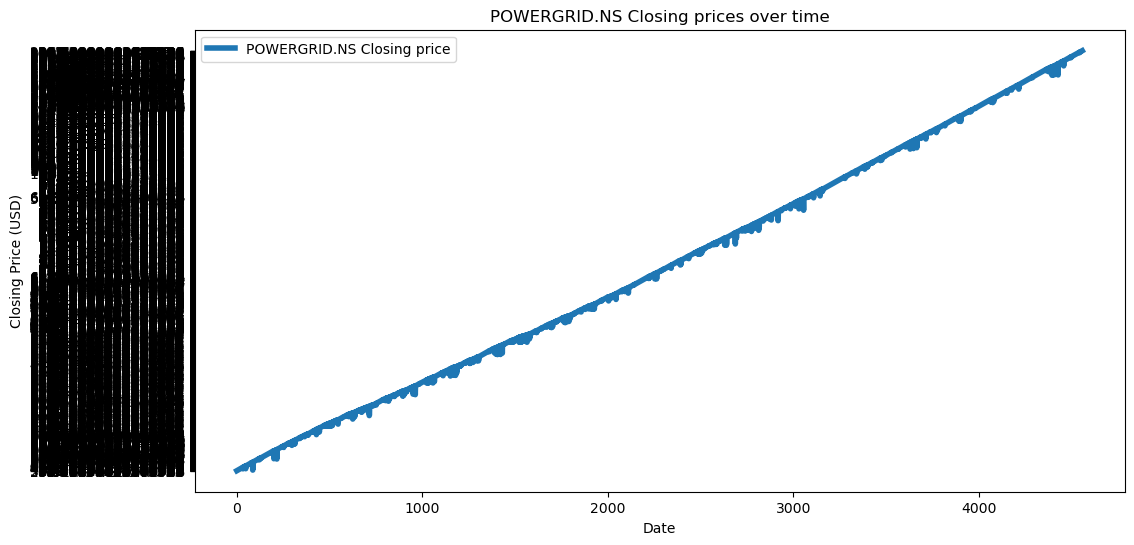

In [40]:
plt.figure(figsize=[12, 6])
plt.plot(powerdf['Close'], label=f'{stock} Closing price', linewidth = 4)
plt.title(f'{stock} Closing prices over time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.show()